In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

In [ ]:
df_churn=pd.read_csv("synthetic_customer_churn_100k.csv")

In [ ]:
df_churn.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


# STEP 1 : EDA

In [ ]:
print("Rows:",df_churn.shape[0])
print("Columns:",df_churn.shape[1])

Rows: 100000
Columns: 9


In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [ ]:
df_churn.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
TotalCharges,0
Churn,0


In [ ]:
df_churn.duplicated().sum()

np.int64(0)

In [ ]:
df_churn['Churn'].value_counts()

,count
Churn,
No,66856
Yes,33144


In [ ]:
df_churn['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.66856
Yes,0.33144


/tmp/ipykernel_27836/2969754036.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_churn,palette=['#06d6a0','#ef476f'])


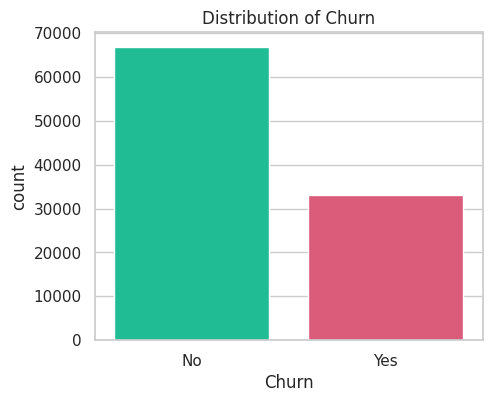

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df_churn,palette=['#06d6a0','#ef476f'])
plt.title("Distribution of Churn")
plt.show()

In [ ]:
df_churn=df_churn.drop(columns=['CustomerID'])

In [ ]:
numerical_cols = df_churn.select_dtypes(include =['int64','float64']).columns
numerical_cols

Index(['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


. Exploratory data analysis
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


Text(0, 0.5, 'Number of Customers')

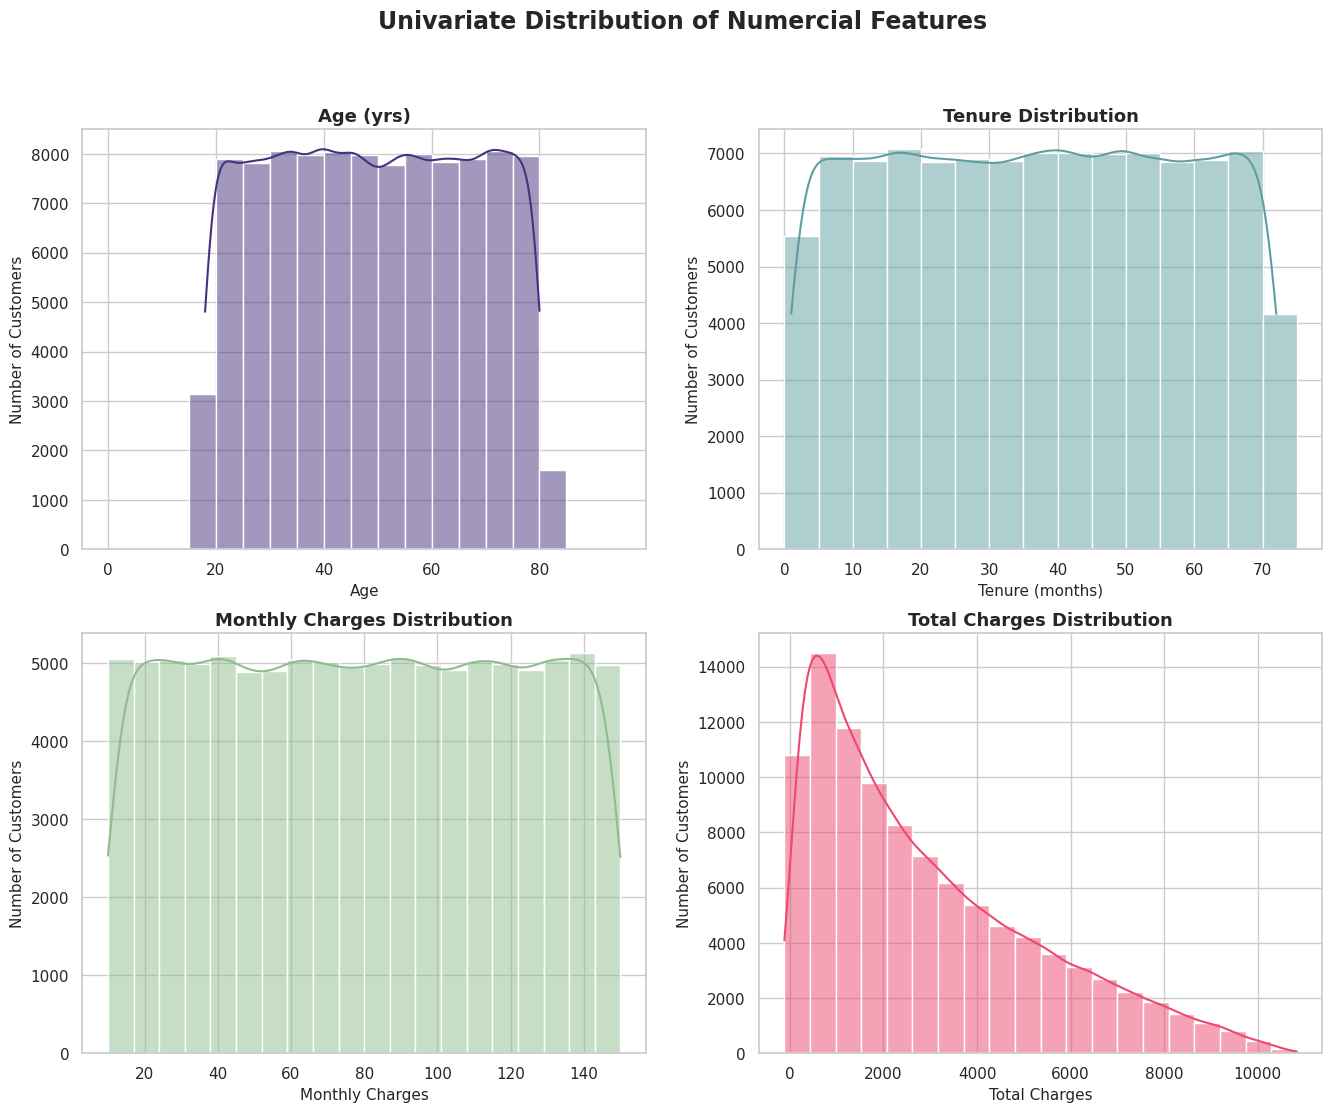

In [ ]:
print("\n. Exploratory data analysis")
print("-" * 272)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.titlesize": 17,
    "axes.titleweight": "bold"
})


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Univariate Distribution of Numercial Features", fontweight="bold")
axes = axes.flatten()

sns.histplot(df_churn["Age"], bins=range(0, 100, 5), kde=True, ax=axes[0])
axes[0].set_title("Age (yrs)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Customers")

sns.histplot(df_churn["Tenure"], bins=range(0, 80, 5), kde=True, ax=axes[1],color="#5f9ea0")
axes[1].set_title("Tenure Distribution")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Number of Customers")


sns.histplot(df_churn["MonthlyCharges"], bins=20, kde=True, ax=axes[2],color="#8fbc8f")
axes[2].set_title("Monthly Charges Distribution")
axes[2].set_xlabel("Monthly Charges")
axes[2].set_ylabel("Number of Customers")


sns.histplot(df_churn["TotalCharges"], bins=20, kde=True, ax=axes[3],color="#ef476f")
axes[3].set_title("Total Charges Distribution")
axes[3].set_xlabel("Total Charges")
axes[3].set_ylabel("Number of Customers")


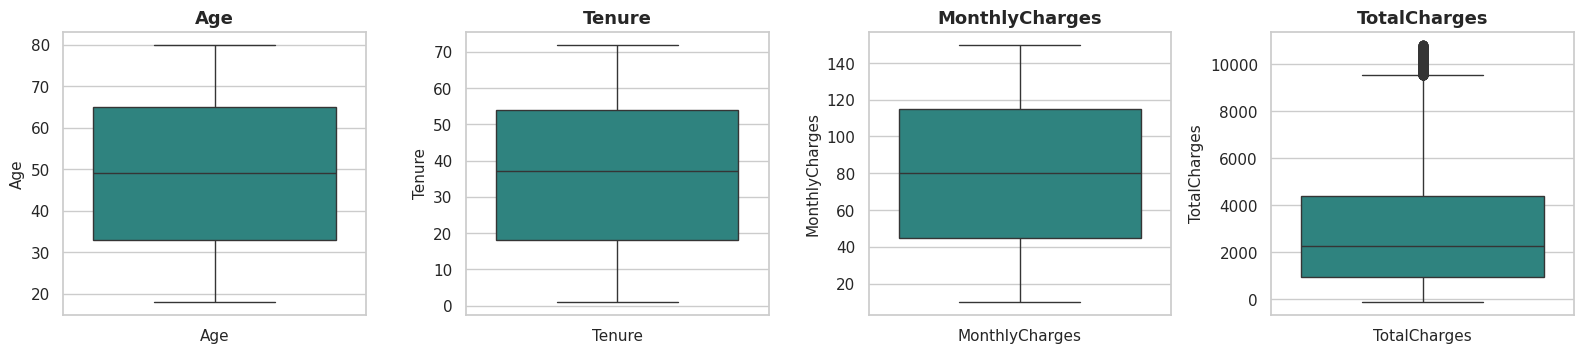

In [ ]:
plt.figure(figsize=(16,10))
for i, col in enumerate(numerical_cols, 1):
  plt.subplot(3,4,i)
  sns.boxplot(x=[col]*len(df_churn),y=df_churn[col],hue=[col]*len(df_churn),palette="viridis",legend=False)
  plt.title(col)
plt.tight_layout()
plt.show()

Bivariate Analysis

/tmp/ipykernel_27836/3756756681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y = col, data = df_churn,palette=["#06d6a0", "#ef476f"])


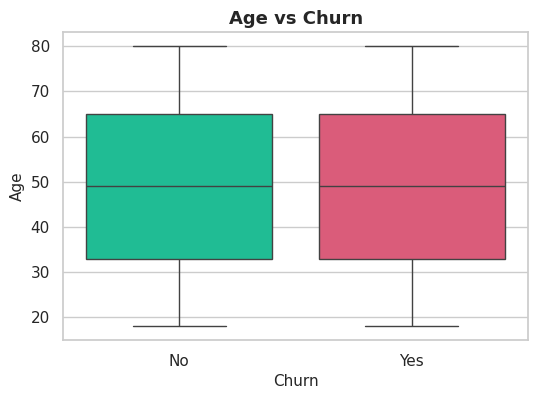

/tmp/ipykernel_27836/3756756681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y = col, data = df_churn,palette=["#06d6a0", "#ef476f"])


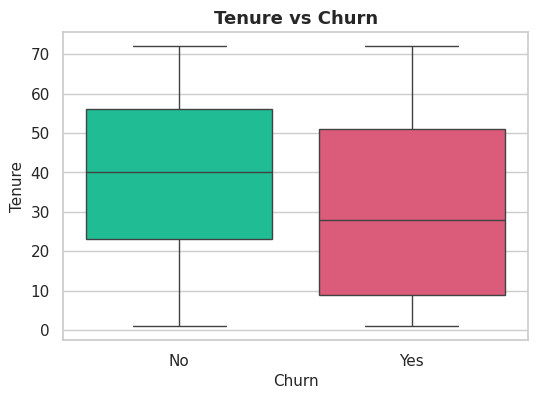

/tmp/ipykernel_27836/3756756681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y = col, data = df_churn,palette=["#06d6a0", "#ef476f"])


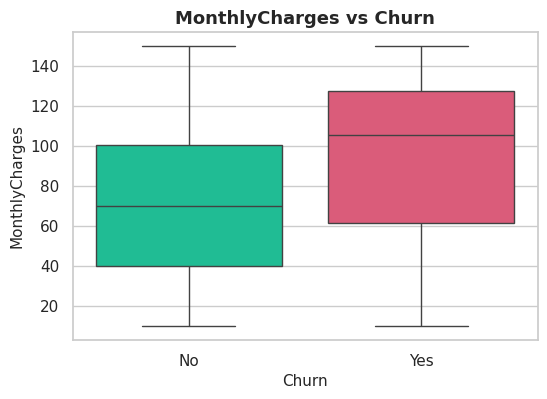

/tmp/ipykernel_27836/3756756681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y = col, data = df_churn,palette=["#06d6a0", "#ef476f"])


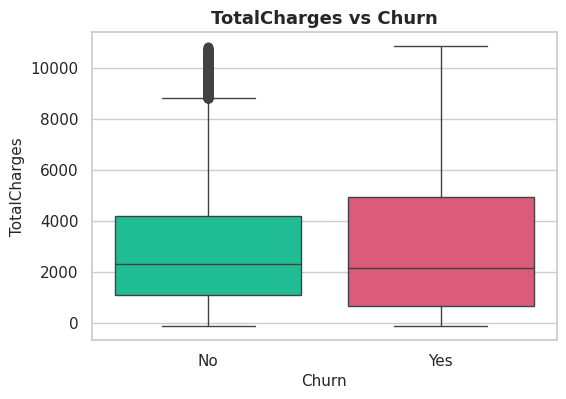

In [ ]:
for col in numerical_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x='Churn', y = col, data = df_churn,palette=["#06d6a0", "#ef476f"])
  plt.title(f"{col} vs Churn")
  plt.show()

In [ ]:
df_churn.groupby('Churn')[numerical_cols].mean()

,Age,Tenure,MonthlyCharges,TotalCharges
Churn,,,,
No,49.102429,39.321796,72.845838,2886.019353
Yes,48.875573,30.889784,94.355298,3007.069627


In [ ]:
corr_matrix = df_churn[numerical_cols].corr()
corr_matrix

,Age,Tenure,MonthlyCharges,TotalCharges
Age,1.000000,0.007915,0.004835,0.008958
Tenure,0.007915,1.000000,0.005976,0.700959
MonthlyCharges,0.004835,0.005976,1.000000,0.623864
TotalCharges,0.008958,0.700959,0.623864,1.000000


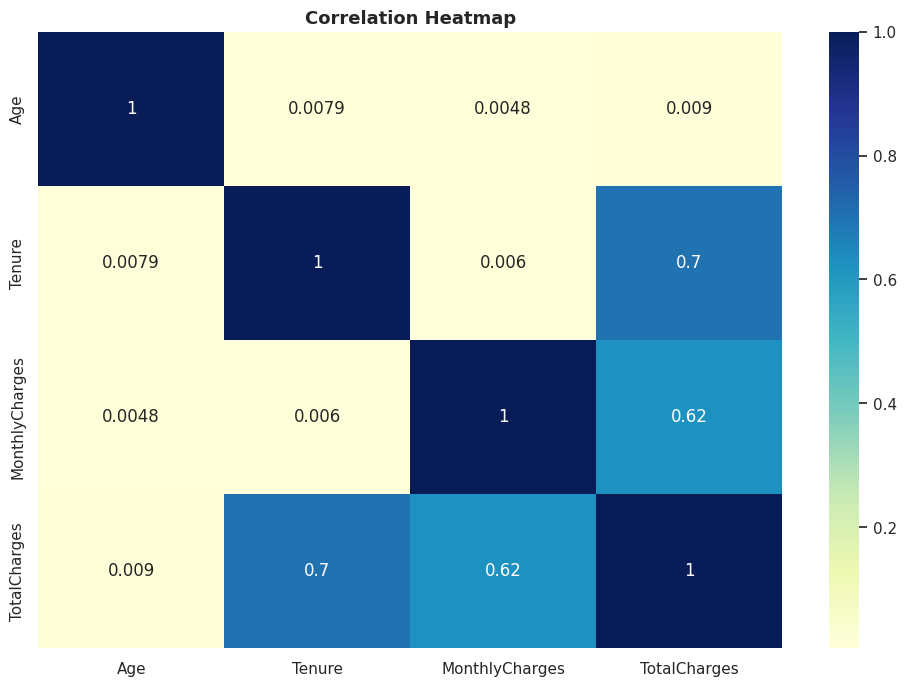

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='YlGnBu', annot= True,)
plt.title("Correlation Heatmap")
plt.show()

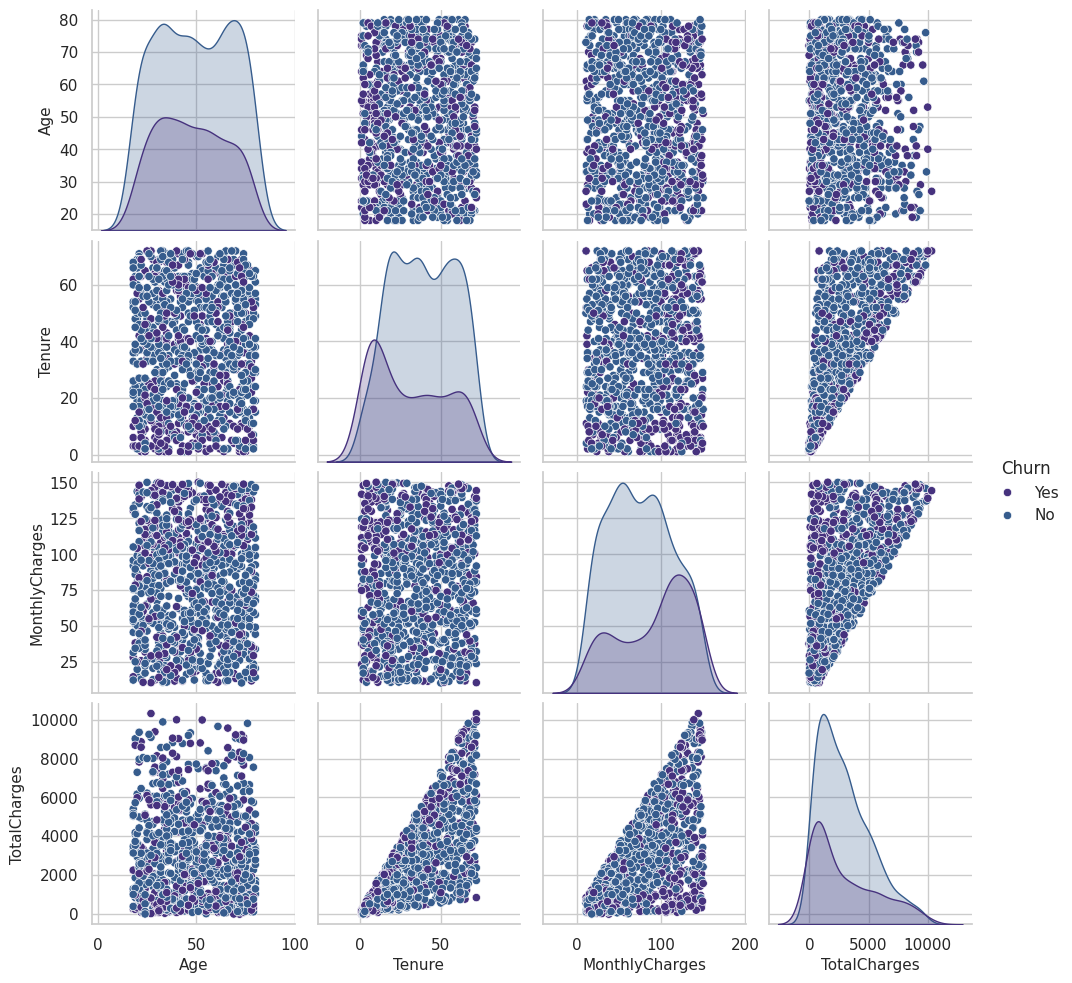

In [ ]:
sns.pairplot(df_churn.sample(1000,random_state=42), hue='Churn',diag_kind = 'kde')
plt.show()

Distribution of each variable

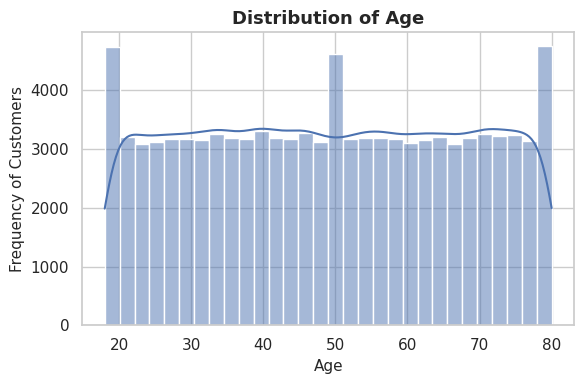

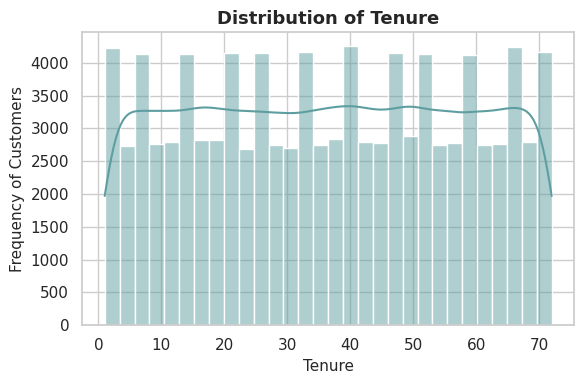

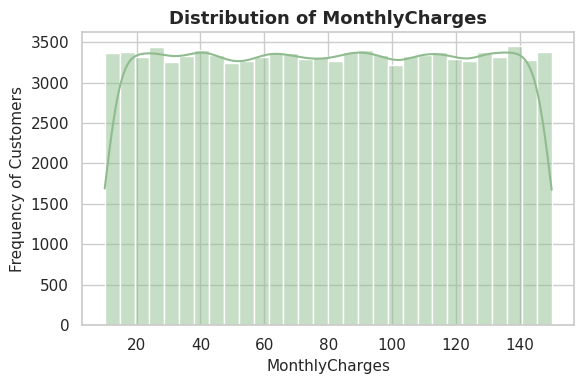

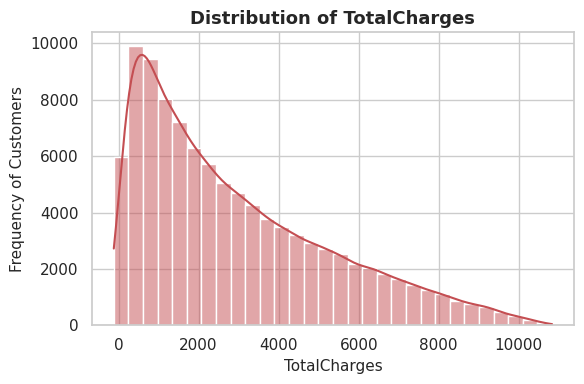

In [ ]:
sns.set_style("whitegrid")

color_map={
    "Age": "#4C72B0",
    "Tenure": "#5F9EA0",
    "MonthlyCharges": "#8FBC8F",
    "TotalCharges": "#C44E52"
}


for col in numerical_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df_churn[col],bins=30,kde = True,color=color_map.get(col,"#2E86B"))
  plt.title(f"Distribution of {col}",fontsize=13)
  plt.xlabel(col)
  plt.ylabel("Frequency of Customers")
  plt.tight_layout()
  plt.show()



Distribution of Varibles by Churn

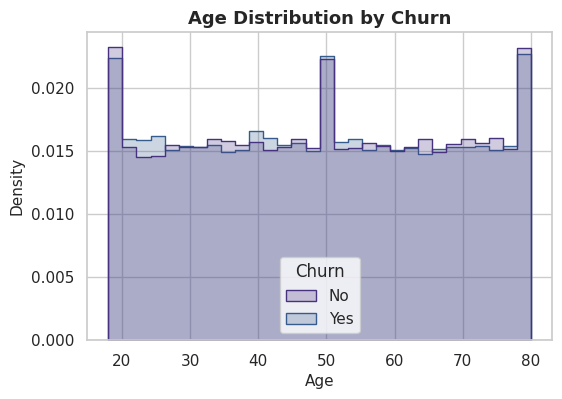

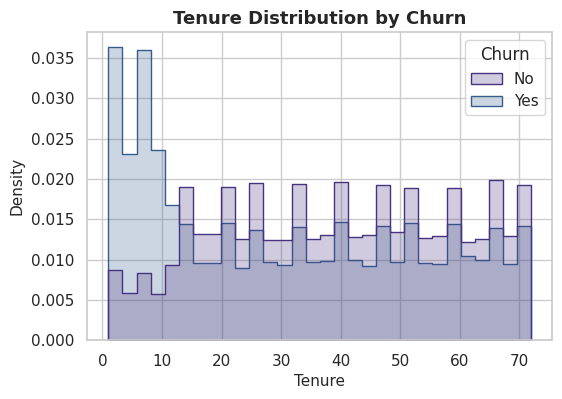

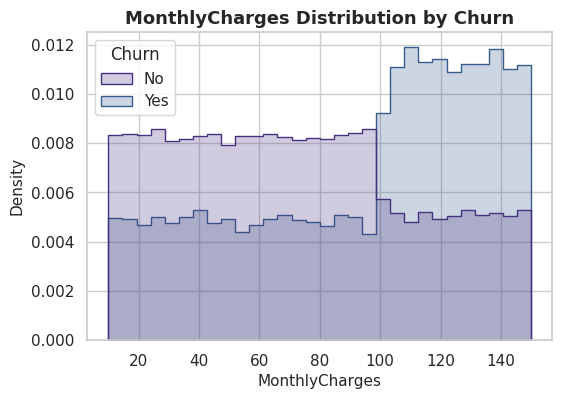

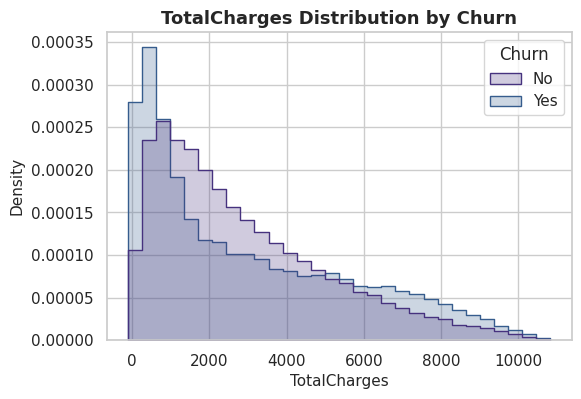

In [ ]:
for col in numerical_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(data=df_churn, x=col, hue='Churn', bins=30, stat='density', common_norm=False, element='step')
  plt.title(f"{col} Distribution by Churn")
  plt.show()

Target Variable Distribution

/tmp/ipykernel_27836/985870445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data = df_churn,palette="viridis")


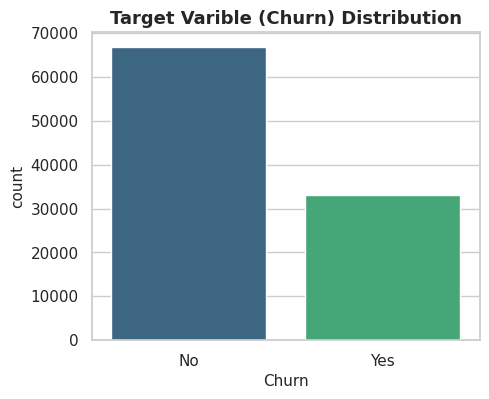

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data = df_churn,palette="viridis")
plt.title("Target Varible (Churn) Distribution")
plt.show()

In [ ]:
distribution_summary = df_churn[numerical_cols].agg(['mean','median','std','min','max','skew']).T
distribution_summary

,mean,median,std,min,max,skew
Age,49.027240,49.00,18.177862,18.00,80.00,0.001385
Tenure,36.527090,37.00,20.789552,1.00,72.00,-0.002218
MonthlyCharges,79.974933,80.00,40.491961,10.00,150.00,-0.000156
TotalCharges,2926.140256,2268.06,2388.163672,-118.43,10831.46,0.916345


# STEP 2 : DATA PREPROCESSING (PREPARATION)

Data Encoding

In [ ]:
df_churn['Churn'] = df_churn['Churn'].map({'No':0,'Yes':1})

In [ ]:
categorical_cols = df_churn.select_dtypes(include=['object']).columns
categorical_cols

Index(['Gender', 'Contract', 'PaymentMethod'], dtype='object')

Traget Split

In [ ]:
X = df_churn.drop(columns=['Churn'])
y = df_churn['Churn']

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [ ]:
for col in categorical_cols:
  X_train[col] = X_train[col].astype('category').cat.codes
  X_test[col] = X_test[col].astype('category').cat.codes

In [ ]:
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)

X_train shape: (80000, 7)
X_test shape: (20000, 7)


In [ ]:
X_train.head(5)

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges
60238,32,1,62,86.12,1,1,5323.85
61520,58,0,69,70.77,1,0,4920.71
85532,23,0,28,148.25,1,1,4112.72
11491,70,0,66,114.41,2,3,7484.61
2797,76,1,62,95.09,0,1,5900.87


In [ ]:
X_test.head(5)

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges
82165,70,2,42,13.46,1,2,574.40
87164,35,0,70,75.06,1,1,5243.05
17248,56,1,49,49.11,1,3,2465.18
92852,27,1,41,71.44,0,0,2923.30
22025,25,2,1,130.19,1,1,72.31


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# STEP 3 : Model Creation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

1. Logistic Regression (Baseline Model)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

2. Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=50, random_state=42,class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

3. Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42,class_weight='balanced')
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

4. XG-Boost

In [ ]:
from xgboost import XGBClassifier

scale = len(y_train[y_train==0])/len(y_train[y_train==1])

xgb_model = XGBClassifier(n_estimators=200,learning_rate=0.1,max_depth=5,subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',scale_pos_weight=scale,random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
def evaluate_train_test(model, X_train, X_test, y_train, y_test, name):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  # print(f"\n{name}")
  # print("------ TRAIN RESULTS ------")
  # print("Accuracy: ", accuracy_score(y_train, y_train_pred))
  # print("Precision: ", precision_score(y_train, y_train_pred))
  # print("Recall: ", recall_score(y_train, y_train_pred))
  # print("F1: ", f1_score(y_train, y_train_pred))

  # print("------ TEST RESULTS ------")
  # print("Accuracy: ", accuracy_score(y_test, y_test_pred))
  # print("Precision: ", precision_score(y_test, y_test_pred))
  # print("Recall: ", recall_score(y_test, y_test_pred))
  # print("F1: ", f1_score(y_test, y_test_pred))

  return{
      'Model' : name,
      "Train Accuracy" : accuracy_score(y_train, y_train_pred),
      "Train Precision" : precision_score(y_train, y_train_pred),
      "Train Recall" : recall_score(y_train, y_train_pred),
      "Train F1" : f1_score(y_train, y_train_pred),
      "Test Accuracy" : accuracy_score(y_test, y_test_pred),
      "Test Precision" : precision_score(y_test, y_test_pred),
      "Test Recall" : recall_score(y_test, y_test_pred),
      "Test F1" : f1_score(y_test, y_test_pred)
  }

In [ ]:
results =[]

results.append(evaluate_train_test(log_model,X_train,X_test,y_train,y_test,"Logistic Regression"))
results.append(evaluate_train_test(dt_model,X_train,X_test,y_train,y_test,"Decision Tree"))
results.append(evaluate_train_test(rf_model,X_train,X_test,y_train,y_test,"Random Forest"))
results.append(evaluate_train_test(xgb_model,X_train,X_test,y_train,y_test,"XGBoost"))

results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.677950,0.510147,0.711974,0.594395,0.67730,0.509385,0.716398,0.595411
1,Decision Tree,0.753287,0.631123,0.615199,0.623059,0.75365,0.630562,0.620003,0.625238
2,Random Forest,0.999875,0.999962,0.999661,0.999811,0.73130,0.621116,0.485443,0.544962
3,XGBoost,0.761062,0.621296,0.714765,0.664761,0.72510,0.574028,0.661487,0.614662


Feature Importance

1. Logistic Regression

In [ ]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())
print("AIC : ",result.aic)

Optimization terminated successfully.
         Current function value: 0.532650
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79992
Method:                           MLE   Df Model:                            7
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.1614
Time:                        11:01:26   Log-Likelihood:                -42612.
converged:                       True   LL-Null:                       -50815.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.2924      0.018    -15.842      0.000      -0.329      -0.256
Age              

In [ ]:
X_reduced = X_train.drop(columns=['Gender','PaymentMethod'])
X_reduced_sm = sm.add_constant(X_reduced)
model_reduced = sm.Logit(y_train, X_reduced_sm).fit()
print("Old AIC : ",85239.98401587801)
print("New AIC : ",model_reduced.aic)

Optimization terminated successfully.
         Current function value: 0.532677
         Iterations 6
Old AIC :  85239.98401587801
New AIC :  85240.32306693992


2. Random Forest

In [ ]:
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

rf_importance

,Feature,Importance
3,MonthlyCharges,0.288729
6,TotalCharges,0.221261
2,Tenure,0.177977
0,Age,0.136929
4,Contract,0.127041
5,PaymentMethod,0.030581
1,Gender,0.017483


3. Decision Tree

In [ ]:
dt_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

dt_importance

,Feature,Importance
4,Contract,0.355003
3,MonthlyCharges,0.328947
2,Tenure,0.314157
0,Age,0.000759
6,TotalCharges,0.000648
1,Gender,0.000486
5,PaymentMethod,0.000000


4. XGBOOST

In [ ]:
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance',ascending=False)

xgb_importance

,Feature,Importance
4,Contract,0.688058
3,MonthlyCharges,0.112865
2,Tenure,0.110877
6,TotalCharges,0.056932
0,Age,0.011105
1,Gender,0.010126
5,PaymentMethod,0.010036


SHAP Feature Analysis

In [ ]:
import shap

1. XGBoost Forest

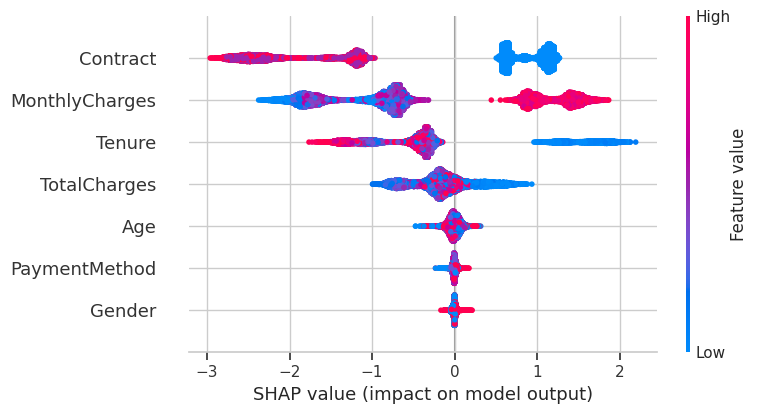

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test)

2. Random Forest

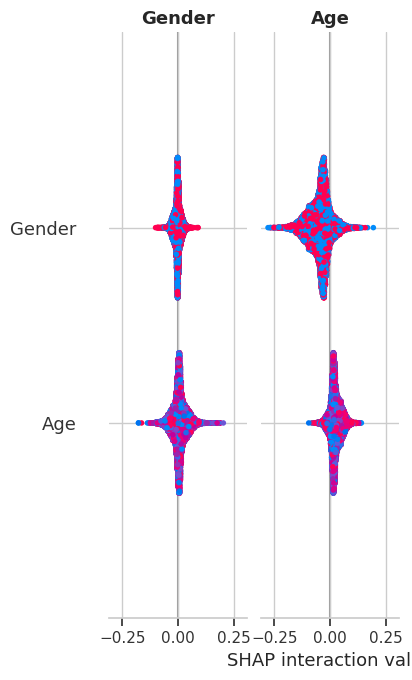

In [ ]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf, X_test)

3. Decision Tree

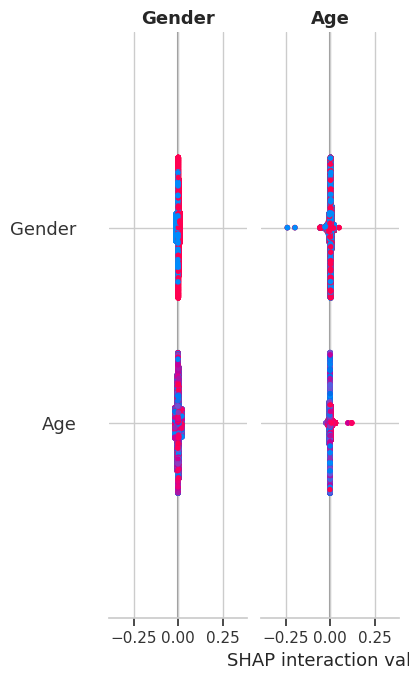

In [ ]:
explainer_dt = shap.TreeExplainer(dt_model)
shap_values_dt = explainer_dt.shap_values(X_test)
shap.summary_plot(shap_values_dt, X_test)

Threshold Tuning

In [ ]:
y_prob_log=log_model.predict_proba(X_test)[:,1]

In [ ]:
thresholds=[0.3,0.4,0.5,0.6]

threshold_res=[]

for t in thresholds:
  y_pred_tuned=(y_prob_log>=t).astype(int)

  threshold_res.append({
      'Threshold':t,
      'Recall':recall_score(y_test,y_pred_tuned),
      'Precision':precision_score(y_test,y_pred_tuned),
      'F1':f1_score(y_test,y_pred_tuned)
  })

  threshold_df=pd.DataFrame(threshold_res)
  threshold_df

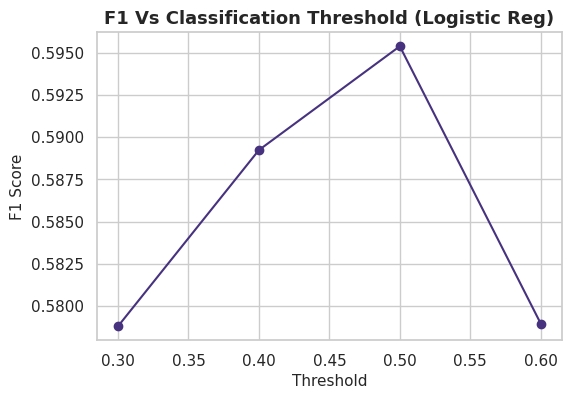

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
plt.plot(threshold_df['Threshold'],threshold_df['F1'],marker='o')
plt.title("F1 Vs Classification Threshold (Logistic Reg)")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.show()

In [ ]:
best_threshold = threshold_df.loc[threshold_df['F1'].idxmax(), 'Threshold']
print("Best Threshold: ", best_threshold)
y_pred_log_final=(y_prob_log>=best_threshold).astype(int)

Best Threshold:  0.5


Confusion Matrix Visualisation

In [ ]:
def plot_confusion_matrix(y_true,y_pred,title):
  cm=confusion_matrix(y_true,y_pred)
  sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(title)
  plt.show()

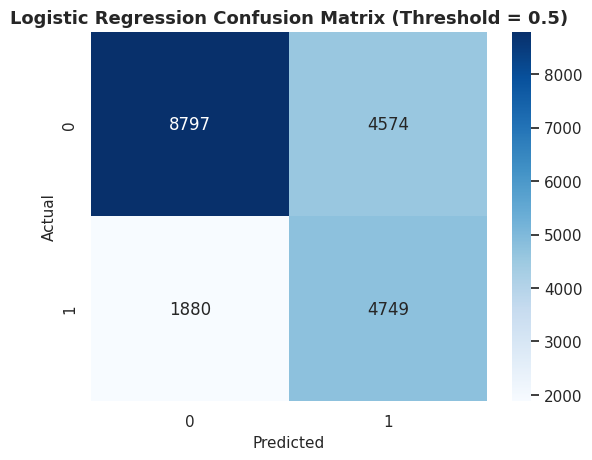

In [ ]:
plot_confusion_matrix(
    y_test,
    y_pred_log_final,
    f"Logistic Regression Confusion Matrix (Threshold = {best_threshold})"
)

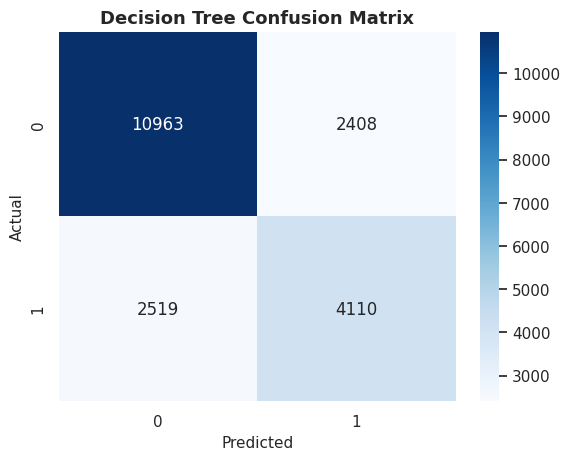

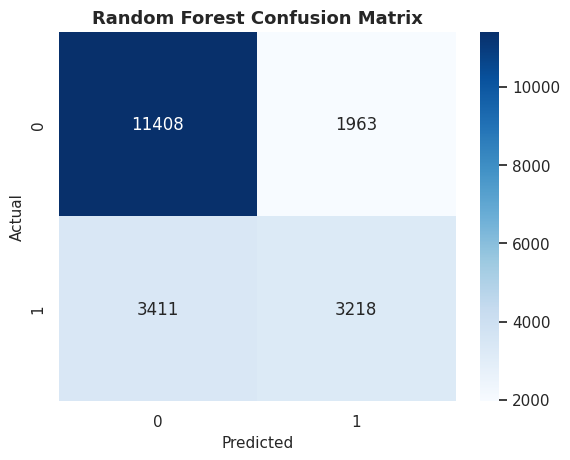

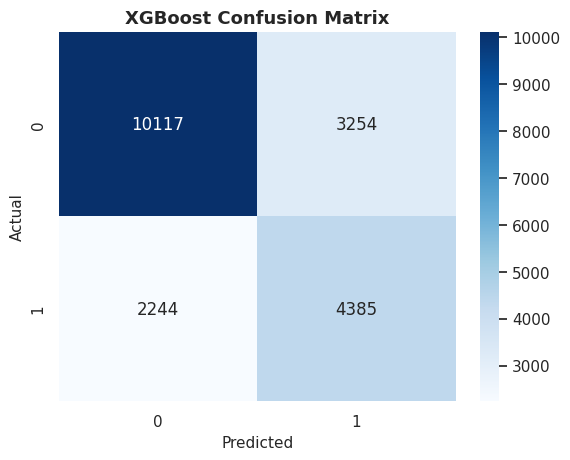

In [ ]:
# plot_confusion_matrix(y_test,y_pred_log,"Logistic Regression Confusion Matrix")
plot_confusion_matrix(y_test,y_pred_dt,"Decision Tree Confusion Matrix")
plot_confusion_matrix(y_test,y_pred_rf,"Random Forest Confusion Matrix")
plot_confusion_matrix(y_test,y_pred_xgb,"XGBoost Confusion Matrix")

ROC Curve Comparision

In [ ]:
y_prob_log=log_model.predict_proba(X_test)[:,1]
y_prob_dt=dt_model.predict_proba(X_test)[:,1]
y_prob_rf=rf_model.predict_proba(X_test)[:,1]
y_prob_xgb=xgb_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

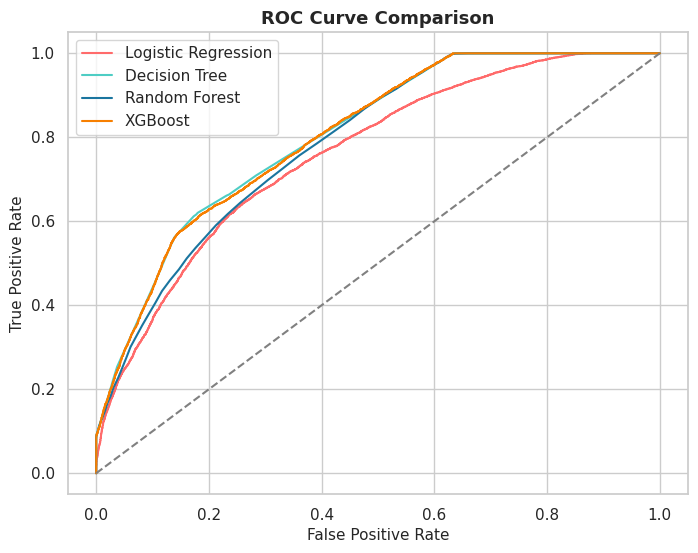

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, color="#ff6b6b", label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, color="#4ecdc4", label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, color="#1a759f", label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, color="#f77f00", label="XGBoost")

plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()